# Positional Flexibility Model — Analysis & Diagnostics
**Model:** KNN (k=15, inverse-distance weighted)  
**Version:** v4 | **Label strategy:** snap_share × career quality  
**Train:** 2000–2020 (2,580 players) | **Holdout:** 2021+ (813 players)

In [5]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Resolve repo root regardless of where Jupyter was launched from
_cwd = Path('.').resolve()
REPO = _cwd if _cwd.name == 'nfl-model-platform' else _cwd.parent
assert (REPO / 'serving').exists(), f"Couldn't find repo root, got: {REPO}"

sys.path.insert(0, str(REPO))

VERSION = 'v7'           # ← change to whichever artifact version you want
ART  = REPO / 'artifacts' / 'positional_flexibility' / VERSION
FEAT = ART / 'features'
print('Repo:', REPO)
print('Artifact files:', sorted(f.name for f in ART.iterdir()))

Repo: /Users/samuel/nfl-model-platform
Artifact files: ['features', 'metadata.json', 'model.pkl', 'train_features.parquet']


## 1 · Load Model & Artifacts

In [6]:
from serving.models.positional_flexibility.model import (
    PositionalFlexibilityModel,
    VIABLE_BACKUP_PERCENTILE,
    PACKAGE_PLAYER_PERCENTILE,
)
from serving.models.positional_flexibility.features import (
    FEATURE_COLS, LABEL_COLS, POSITION_GROUP_ORDER,
)

model = PositionalFlexibilityModel(k=15)
model.load(ART)

holdout_df  = pd.read_parquet(FEAT / 'holdout.parquet')
player_meta = pd.read_parquet(FEAT / 'player_meta.parquet')
train_meta  = pd.read_parquet(ART / 'train_features.parquet')
meta        = json.loads((ART / 'metadata.json').read_text())

feat_cols  = [c for c in FEATURE_COLS if c in holdout_df.columns]
label_cols = [c for c in LABEL_COLS   if c in holdout_df.columns]

X_holdout = holdout_df[feat_cols]
y_holdout = holdout_df[label_cols]

train_y = model._train_y
train_X = model._train_X
primary_group = player_meta['primary_group'].values
n = min(len(train_X), len(train_y))

palette = {'QB':'#e74c3c','SKILL':'#3498db','OL':'#2ecc71',
           'DL':'#e67e22','LB':'#9b59b6','DB':'#1abc9c','SPEC':'#95a5a6'}

print(f'Holdout: {len(holdout_df)} | Training: {n} | Features: {len(feat_cols)}')

Holdout: 823 | Training: 4053 | Features: 23


## 2 · Holdout Performance Summary

position  spearman_r    mae  n_pos  base_rate
      QB      0.2601 0.1050    726   0.882139
   SKILL      0.3979 0.1078    726   0.882139
      OL      0.4706 0.0665    726   0.882139
      DL      0.3872 0.0874    726   0.882139
      LB      0.3730 0.0963    726   0.882139
      DB      0.4319 0.0978    726   0.882139
    SPEC      0.2792 0.1106    726   0.882139

Macro Spearman ρ : 0.3714
Macro MAE        : 0.0959


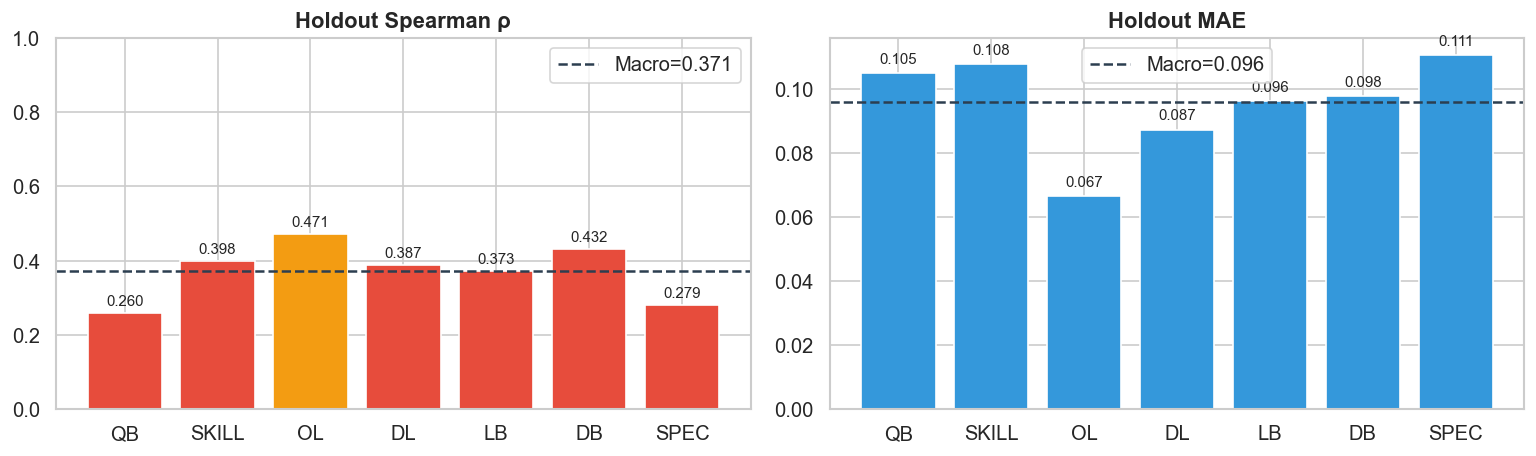

In [7]:
hm   = meta['holdout_metrics']
perf = pd.DataFrame(hm['per_position']).T.reset_index().rename(columns={'index':'position'})
for c in ['spearman_r','mae']: perf[c] = perf[c].astype(float)
for c in ['n_pos','n_total']:  perf[c] = perf[c].astype(int)
perf['base_rate'] = perf['n_pos'] / perf['n_total']

print(perf[['position','spearman_r','mae','n_pos','base_rate']].to_string(index=False))
print(f'\nMacro Spearman ρ : {hm["macro_spearman_r"]:.4f}')
print(f'Macro MAE        : {hm["macro_mae"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#e74c3c' if r<0.45 else '#f39c12' if r<0.65 else '#27ae60' for r in perf['spearman_r']]

axes[0].bar(perf['position'], perf['spearman_r'], color=colors, edgecolor='white')
axes[0].axhline(hm['macro_spearman_r'], ls='--', color='#2c3e50', lw=1.5,
                label=f'Macro={hm["macro_spearman_r"]:.3f}')
axes[0].set_ylim(0,1); axes[0].legend()
axes[0].set_title('Holdout Spearman ρ', fontweight='bold')
for i,(r,_) in enumerate(zip(perf['spearman_r'],perf['position'])):
    axes[0].text(i, r+0.02, f'{r:.3f}', ha='center', fontsize=9)

axes[1].bar(perf['position'], perf['mae'], color='#3498db', edgecolor='white')
axes[1].axhline(hm['macro_mae'], ls='--', color='#2c3e50', lw=1.5,
                label=f'Macro={hm["macro_mae"]:.3f}')
axes[1].legend()
axes[1].set_title('Holdout MAE', fontweight='bold')
for i,(r,_) in enumerate(zip(perf['mae'],perf['position'])):
    axes[1].text(i, r+0.003, f'{r:.3f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## 3 · Label Distribution (Training Set)

  pos base_rate mean_nonzero p50_all p70_all p50_nonzero p70_nonzero
   QB     90.3%        0.256   0.249   0.315       0.268       0.326
SKILL     90.3%        0.239   0.192   0.310       0.215       0.325
   OL     90.3%        0.172   0.125   0.183       0.135       0.196
   DL     90.3%        0.222   0.198   0.270       0.212       0.279
   LB     90.3%        0.227   0.201   0.285       0.224       0.296
   DB     90.3%        0.211   0.154   0.272       0.175       0.290
 SPEC     90.3%        0.237   0.224   0.280       0.238       0.288


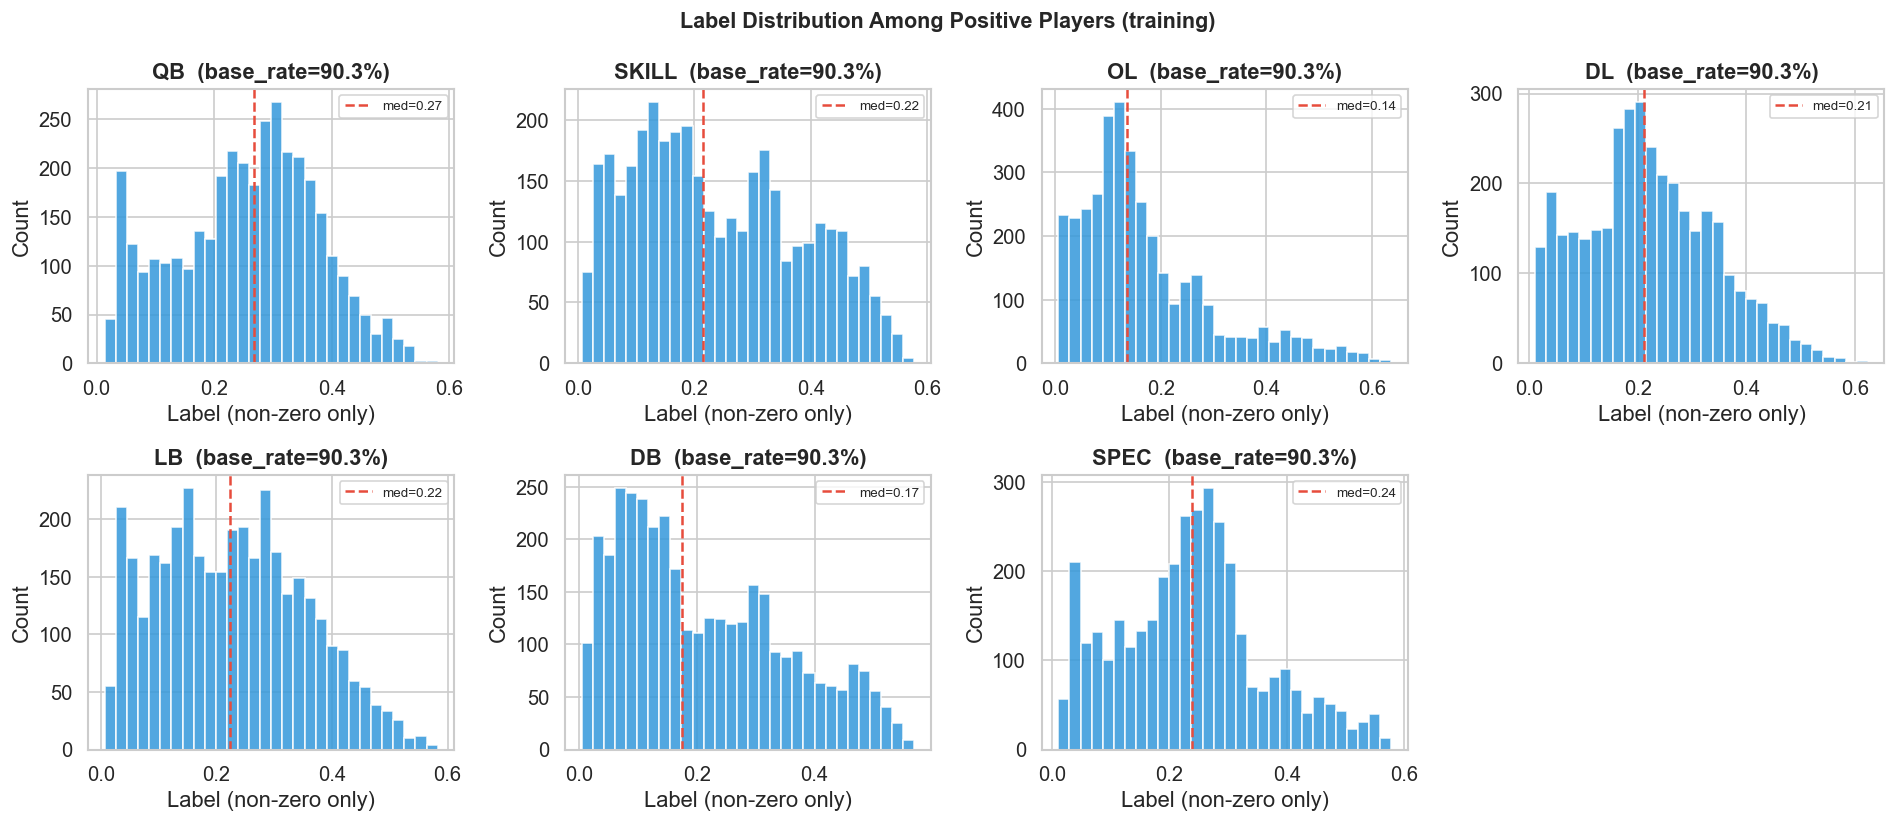

In [8]:
train_labels_df = pd.DataFrame(train_y, columns=label_cols)

stats = []
for grp in POSITION_GROUP_ORDER:
    col = f'label_{grp}'
    if col not in train_labels_df.columns: continue
    v = train_labels_df[col]
    nz = v[v > 0]
    stats.append({'pos': grp, 'base_rate': f'{(v>0).mean():.1%}',
                  'mean_nonzero': f'{nz.mean():.3f}' if len(nz) else 'N/A',
                  'p50_all': f'{v.quantile(0.5):.3f}',
                  'p70_all': f'{v.quantile(0.7):.3f}',
                  'p50_nonzero': f'{nz.quantile(0.5):.3f}' if len(nz) else 'N/A',
                  'p70_nonzero': f'{nz.quantile(0.7):.3f}' if len(nz) else 'N/A'})
print(pd.DataFrame(stats).to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, grp in enumerate(POSITION_GROUP_ORDER):
    col = f'label_{grp}'
    v   = train_labels_df[col]; nz = v[v > 0]
    ax  = axes[i]
    if len(nz):
        ax.hist(nz, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
        ax.axvline(nz.median(), color='#e74c3c', lw=1.5, ls='--', label=f'med={nz.median():.2f}')
        ax.legend(fontsize=8)
    ax.set_title(f'{grp}  (base_rate={(v>0).mean():.1%})', fontweight='bold')
    ax.set_xlabel('Label (non-zero only)'); ax.set_ylabel('Count')
axes[-1].axis('off')
plt.suptitle('Label Distribution Among Positive Players (training)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4 · ⚠️ Threshold Bug Diagnosis

All `viable_backup` / `package_player` thresholds stored in the artifact are **0.0**.

**Root cause:** `np.percentile(col, 70)` on a label vector that is mostly zeros (sparse)
returns 0.0. The fix is to compute percentiles on the **non-zero subpopulation** only —
i.e. *"score ≥ 70th percentile of players who actually played at this position"*.

In [9]:
print('=== Stored (broken) thresholds ===')
for grp, t in meta['thresholds'].items():
    print(f'  {grp:<6}  viable_backup={t["viable_backup"]}  package_player={t["package_player"]}')

print(f'\n=== Fixed: percentile on non-zero population (VIABLE={VIABLE_BACKUP_PERCENTILE}th, PACKAGE={PACKAGE_PLAYER_PERCENTILE}th) ===')
fixed = {}
for i, grp in enumerate(POSITION_GROUP_ORDER):
    col = train_y[:n, i]
    nz  = col[col > 0]
    vb  = float(np.percentile(nz, VIABLE_BACKUP_PERCENTILE))  if len(nz) else 0.0
    pp  = float(np.percentile(nz, PACKAGE_PLAYER_PERCENTILE)) if len(nz) else 0.0
    fixed[grp] = {'viable_backup': vb, 'package_player': pp}
    print(f'  {grp:<6}  viable_backup={vb:.4f}  package_player={pp:.4f}  (n_nonzero={len(nz)})')

model._thresholds = fixed
print('\n✓ Fixed thresholds applied in-memory')

=== Stored (broken) thresholds ===
  QB      viable_backup=0.2769377100613867  package_player=0.2451815212258455
  SKILL   viable_backup=0.29208490304219764  package_player=0.23469393389457058
  OL      viable_backup=0.16552683381649264  package_player=0.12360454129179416
  DL      viable_backup=0.23916851503556918  package_player=0.19284999137557693
  LB      viable_backup=0.26207395558303115  package_player=0.220994842165051
  DB      viable_backup=0.2659885880062226  package_player=0.2028452397281911
  SPEC    viable_backup=0.246514141044835  package_player=0.21187018281504916

=== Fixed: percentile on non-zero population (VIABLE=70th, PACKAGE=50th) ===
  QB      viable_backup=0.3256  package_player=0.2678  (n_nonzero=3659)
  SKILL   viable_backup=0.3250  package_player=0.2152  (n_nonzero=3659)
  OL      viable_backup=0.1957  package_player=0.1351  (n_nonzero=3659)
  DL      viable_backup=0.2794  package_player=0.2119  (n_nonzero=3659)
  LB      viable_backup=0.2959  package_player=

## 5 · Predicted vs Actual (Holdout Scatter)

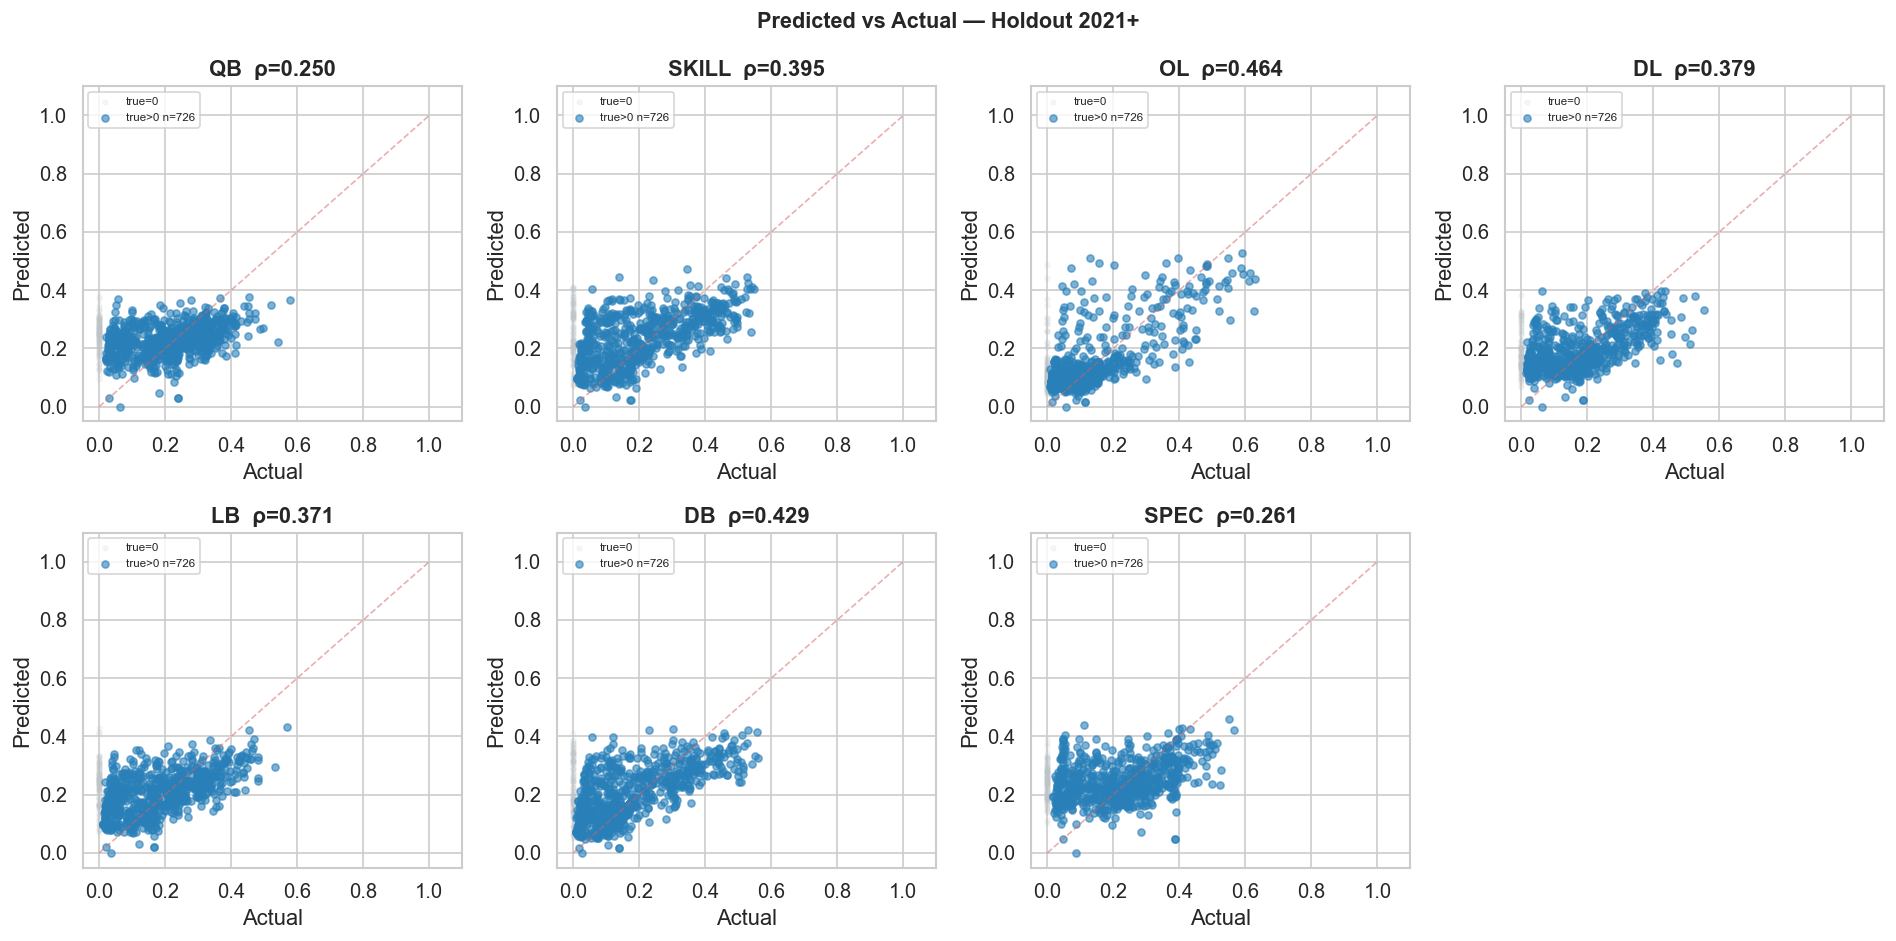

In [10]:
X_scaled   = model._scale(X_holdout)
pred_probs = model._knn_scores(X_scaled)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, grp in enumerate(POSITION_GROUP_ORDER):
    col    = f'label_{grp}'
    y_true = y_holdout[col].values
    y_pred = pred_probs[:, i]
    pos    = y_true > 0
    rho, _ = spearmanr(y_true, y_pred)
    ax     = axes[i]
    ax.scatter(y_true[~pos], y_pred[~pos], alpha=0.12, s=8,  color='#bdc3c7', label='true=0')
    ax.scatter(y_true[pos],  y_pred[pos],  alpha=0.6,  s=18, color='#2980b9', label=f'true>0 n={pos.sum()}')
    ax.plot([0,1],[0,1],'r--',lw=1,alpha=0.5)
    ax.set_title(f'{grp}  ρ={rho:.3f}', fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_xlim(-0.05,1.1); ax.set_ylim(-0.05,1.1)
    ax.legend(fontsize=7)
axes[-1].axis('off')
plt.suptitle('Predicted vs Actual — Holdout 2021+', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 6 · Feature Space — PCA by Primary Position

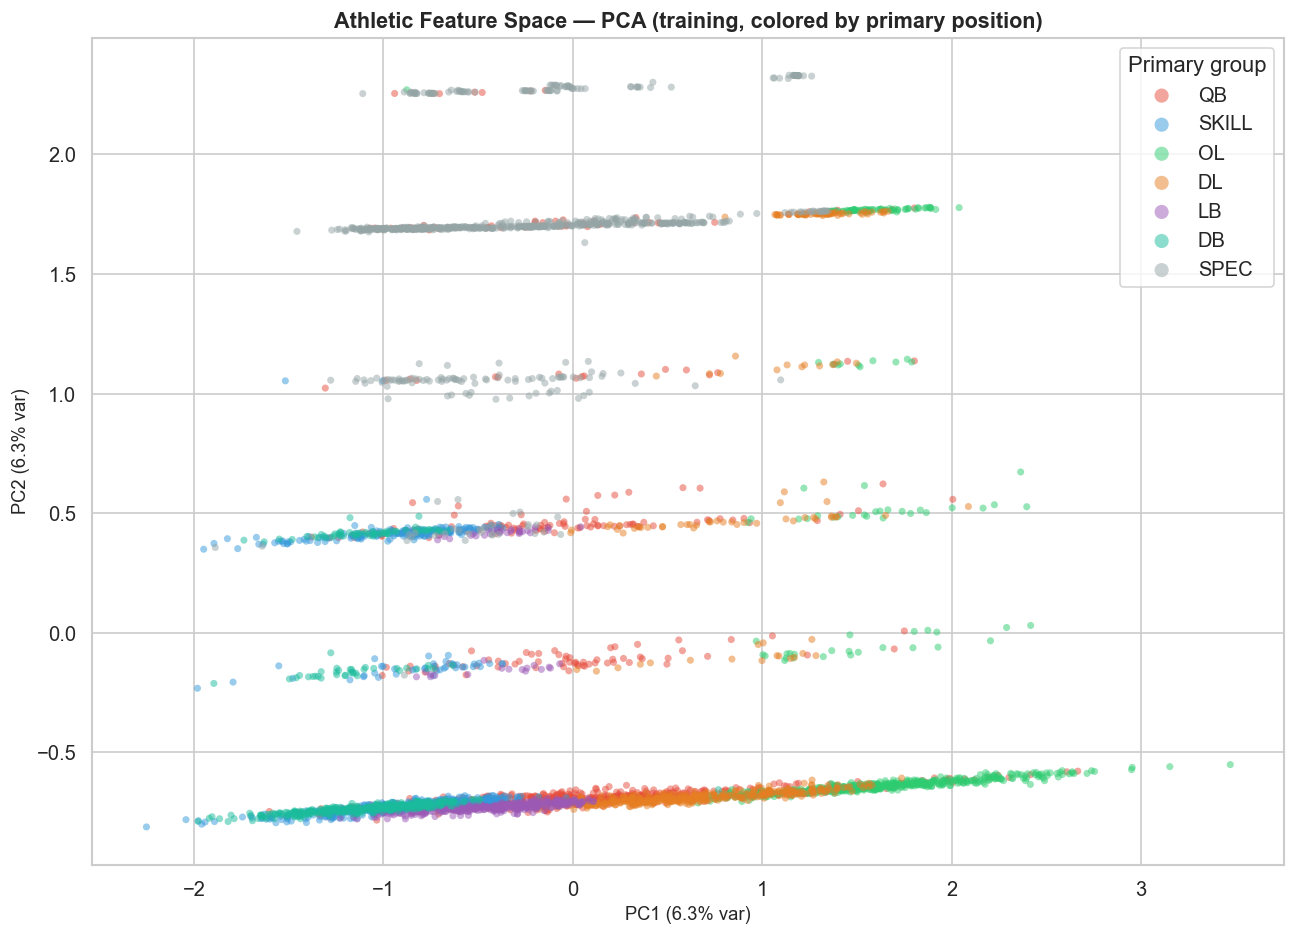

Top drivers of PC1 (size axis):
forty_yard       0.945370
vertical_in      0.207509
three_cone       0.140813
broad_jump_in    0.110532
bench_reps       0.109448
speed_score      0.092365


In [11]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(train_X[:n])

fig, ax = plt.subplots(figsize=(11, 8))
for grp in POSITION_GROUP_ORDER:
    mask = primary_group[:n] == grp
    ax.scatter(coords[mask,0], coords[mask,1],
               c=palette[grp], label=grp, alpha=0.5, s=18, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=11)
ax.set_title('Athletic Feature Space — PCA (training, colored by primary position)',
             fontsize=13, fontweight='bold')
ax.legend(title='Primary group', markerscale=2)
plt.tight_layout(); plt.show()

feat_names = feat_cols
load = pd.DataFrame(pca.components_.T, index=feat_names, columns=['PC1','PC2'])
print('Top drivers of PC1 (size axis):')
print(load['PC1'].abs().sort_values(ascending=False).head(6).to_string())

## 7 · Feature Importance — Permutation on Holdout

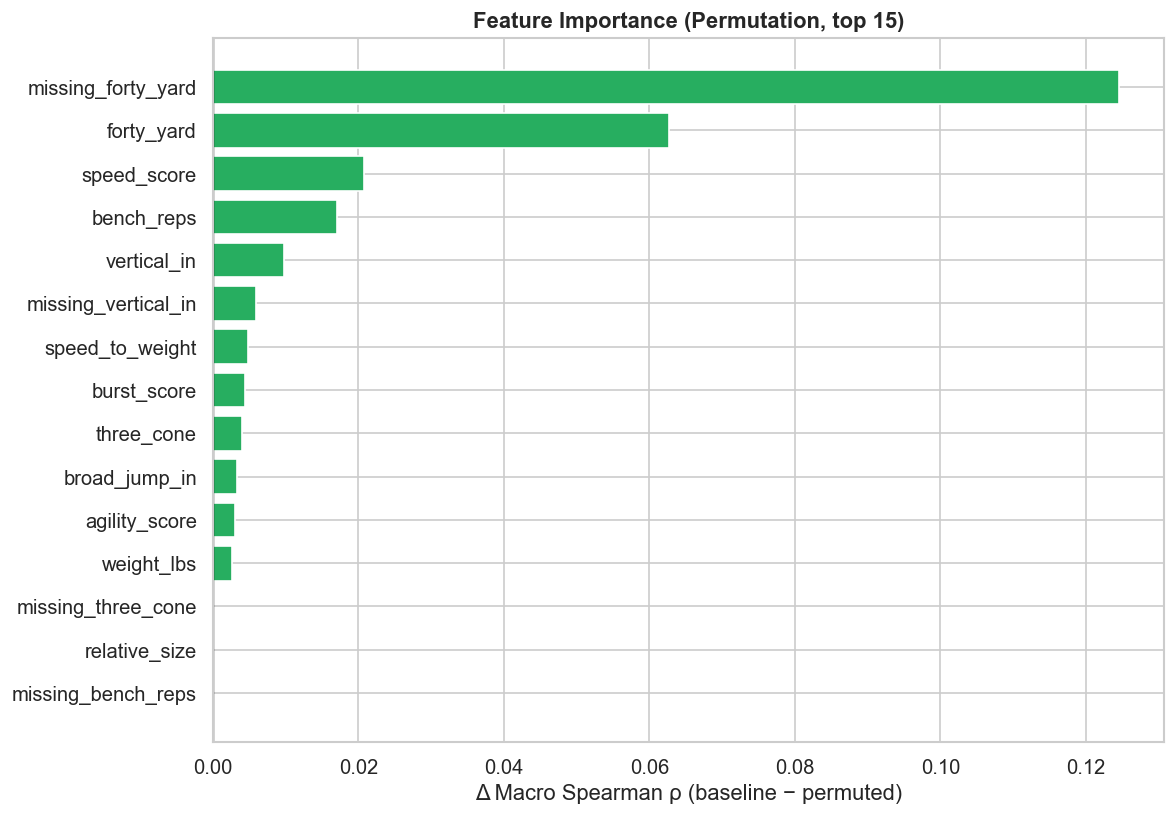

Baseline macro ρ: 0.3505
            feature  importance
 missing_forty_yard    0.124585
         forty_yard    0.062675
        speed_score    0.020839
         bench_reps    0.017010
        vertical_in    0.009787
missing_vertical_in    0.005958
    speed_to_weight    0.004824
        burst_score    0.004465
         three_cone    0.003978
      broad_jump_in    0.003357


In [12]:
X_h = X_holdout[feat_cols].fillna(X_holdout[feat_cols].median()).fillna(0).values
X_h_scaled = model._scaler.transform(X_h)
Y_true     = y_holdout[label_cols].values.astype(float)

def macro_spearman(yt, yp):
    rhos = []
    for i in range(yt.shape[1]):
        if (yt[:,i]>0).sum() < 5: continue
        r,_ = spearmanr(yt[:,i], yp[:,i])
        if not np.isnan(r): rhos.append(r)
    return np.mean(rhos) if rhos else 0.0

base = macro_spearman(Y_true, model._knn_scores(X_h_scaled))
rng  = np.random.default_rng(42)
imps = []
for j, fname in enumerate(feat_cols):
    sc = []
    for _ in range(5):
        Xp = X_h_scaled.copy(); Xp[:,j] = rng.permutation(Xp[:,j])
        sc.append(macro_spearman(Y_true, model._knn_scores(Xp)))
    imps.append({'feature': fname, 'importance': base - np.mean(sc)})

imp_df = pd.DataFrame(imps).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top = imp_df.head(15)
cols = ['#27ae60' if x>0 else '#e74c3c' for x in top['importance']]
ax.barh(top['feature'][::-1], top['importance'][::-1], color=cols[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ Macro Spearman ρ (baseline − permuted)')
ax.set_title('Feature Importance (Permutation, top 15)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Baseline macro ρ: {base:.4f}')
print(imp_df.head(10).to_string(index=False))

## 8 · Position Recall — Confusion Matrix (Training)

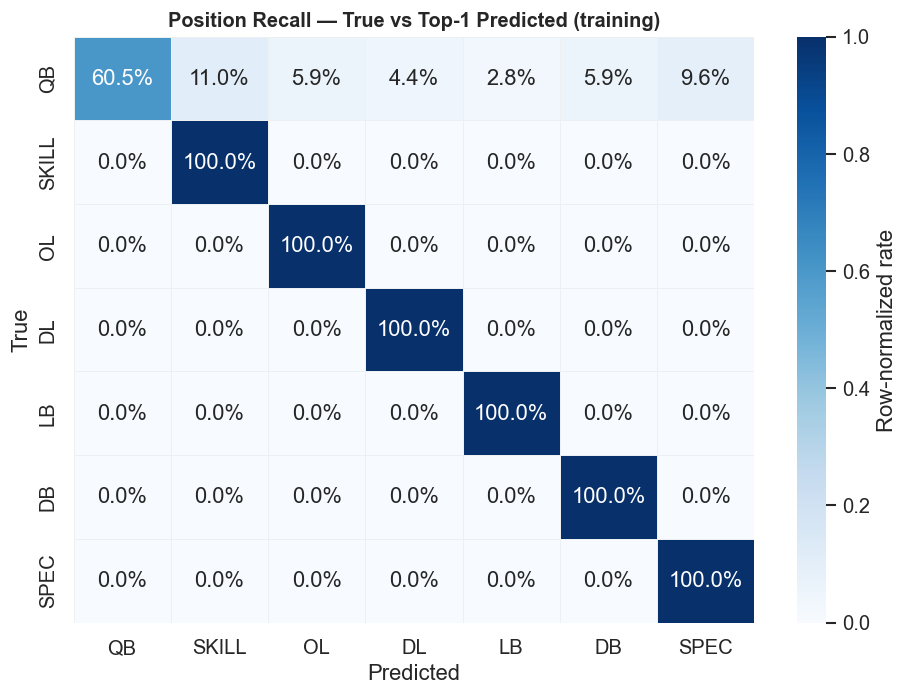

In [13]:
train_probs  = model._knn_scores(train_X[:n])
pred_primary = [POSITION_GROUP_ORDER[np.argmax(r)] for r in train_probs]
true_primary = list(primary_group[:n])

conf = pd.crosstab(
    pd.Series(true_primary, name='True'),
    pd.Series(pred_primary, name='Predicted'),
    normalize='index',
).reindex(index=POSITION_GROUP_ORDER, columns=POSITION_GROUP_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf, annot=True, fmt='.1%', cmap='Blues',
            linewidths=0.5, linecolor='#ecf0f1', ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Row-normalized rate'})
ax.set_title('Position Recall — True vs Top-1 Predicted (training)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 9 · Neighbor Purity by Position
Fraction of k=15 neighbors sharing the same primary position — higher = more separable.

           mean    median
group                    
QB     0.421796  0.400000
SKILL  0.522896  0.533333
OL     0.798811  0.866667
DL     0.569008  0.533333
LB     0.543891  0.533333
DB     0.637116  0.666667
SPEC   0.858275  0.933333


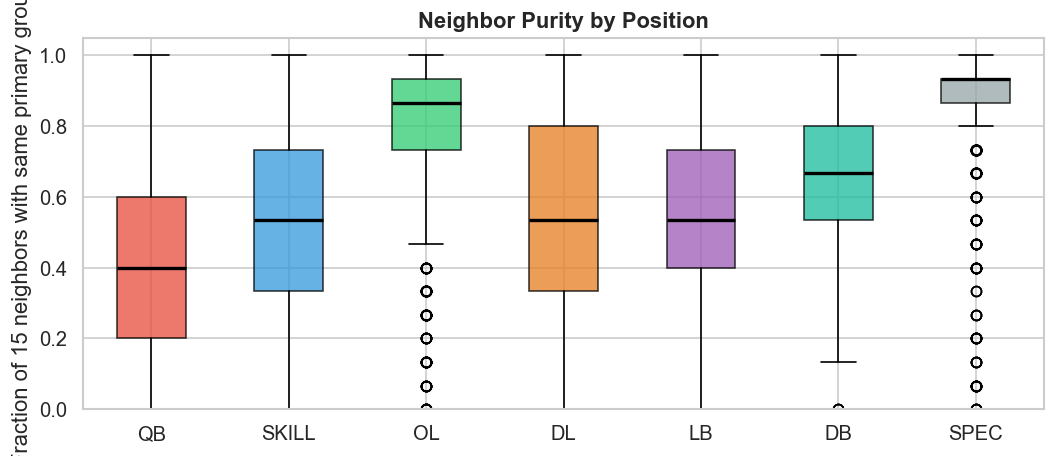

In [14]:
nn16 = NearestNeighbors(n_neighbors=16, algorithm='ball_tree', metric='euclidean')
nn16.fit(train_X[:n])
_, nbr_idx = nn16.kneighbors(train_X[:n])

purity_rows = []
for i in range(n):
    nbrs = nbr_idx[i][1:]   # exclude self
    my   = primary_group[i]
    pur  = sum(primary_group[j]==my for j in nbrs if j < n) / len(nbrs)
    purity_rows.append({'group': my, 'purity': pur})

pur_df = pd.DataFrame(purity_rows)
print(pur_df.groupby('group')['purity'].agg(['mean','median']).reindex(POSITION_GROUP_ORDER).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bp_data = [pur_df[pur_df['group']==g]['purity'].values for g in POSITION_GROUP_ORDER]
bplot   = ax.boxplot(bp_data, labels=POSITION_GROUP_ORDER, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
for patch, grp in zip(bplot['boxes'], POSITION_GROUP_ORDER):
    patch.set_facecolor(palette[grp]); patch.set_alpha(0.75)
ax.set_ylabel('Fraction of 15 neighbors with same primary group')
ax.set_title('Neighbor Purity by Position', fontweight='bold')
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## 10 · Top Flex Candidates — Holdout (2021+)
Highest predicted score at a **non-primary** position group.

In [15]:
flex_rows = []
for idx in range(len(pred_probs)):
    probs = pred_probs[idx]
    order = sorted(range(len(probs)), key=lambda x: -probs[x])
    prim  = POSITION_GROUP_ORDER[order[0]]
    for sec_i in order[1:]:
        sec = POSITION_GROUP_ORDER[sec_i]
        if probs[sec_i] > 0.05:
            flex_rows.append({
                'pred_primary':    prim,
                'pred_secondary':  sec,
                'primary_score':   round(probs[order[0]], 4),
                'secondary_score': round(probs[sec_i], 4),
                'true_primary_lbl':  round(y_holdout[f'label_{prim}'].iloc[idx], 4),
                'true_secondary_lbl': round(y_holdout[f'label_{sec}'].iloc[idx], 4),
            })
            break

flex_df = pd.DataFrame(flex_rows).sort_values('secondary_score', ascending=False)
print(f'Holdout players with secondary score > 0.05: {len(flex_df)}')
print(flex_df.head(20).to_string(index=False))

print('\nMost common flex transitions:')
print(flex_df.groupby(['pred_primary','pred_secondary']).size()
      .reset_index(name='count').sort_values('count', ascending=False).head(10).to_string(index=False))

Holdout players with secondary score > 0.05: 818
pred_primary pred_secondary  primary_score  secondary_score  true_primary_lbl  true_secondary_lbl
       SKILL             DB         0.4715           0.4257            0.3440              0.3032
       SKILL             DB         0.4259           0.4224            0.5304              0.5295
       SKILL             LB         0.4418           0.4213            0.4637              0.4542
       SKILL             DB         0.4341           0.4211            0.2415              0.2293
       SKILL             DB         0.4452           0.4125            0.5270              0.4571
          DB          SKILL         0.4124           0.4120            0.0000              0.0000
          DB          SKILL         0.4145           0.4056            0.5576              0.5486
       SKILL             DB         0.4213           0.4026            0.4897              0.4594
       SKILL             DB         0.4448           0.3979          

## 11 · Example Predictions — Known Flex Players

In [ ]:
def show_player(player_id):
    """Look up a player by player_id (exact, no guessing)."""
    hits = train_meta[train_meta['player_id'] == player_id]
    if hits.empty:
        print(f'No player found with player_id="{player_id}"')
        return
    row = hits.iloc[0]
    idx = hits.index[0]
    print(f'\n=== {row["player_name"]} ({row.get("primary_group","?")}) ===')
    if idx < len(train_X):
        probs = model._knn_scores(train_X[[idx]])[0]
        for grp, p in sorted(zip(POSITION_GROUP_ORDER, probs), key=lambda x: -x[1]):
            t  = model._thresholds.get(grp, {})
            vb = '✓ viable'  if p >= t.get('viable_backup',  9999) else ''
            pp = '✓ package' if p >= t.get('package_player', 9999) else ''
            print(f'  {grp:<6}  {p:.4f}  {vb} {pp}')

for pid in ['00-0031237', '00-0023459', '00-0026035']:   # replace with real player_ids
    show_player(pid)


## 12 · Summary & Action Items

| Finding | Severity | Recommendation |
|---------|----------|----------------|
| All thresholds = 0.0 → every player flagged viable | 🔴 Bug | Compute percentiles on **non-zero population** in `model.py:train()` |
| SPEC Spearman ρ = 0.20 | 🟡 Weak | ST snaps inflate base_rate; consider floor of 50 career ST plays |
| OL Spearman ρ = 0.83 | 🟢 Strong | Most distinct physical profile — model works best here |
| Macro ρ = 0.534 | 🟢 Solid | Meaningful rank correlation across all 7 groups |
| Gold athletic scores missing for some players | 🟡 Note | `speed_to_weight` / `size_score` are most important features — imputation matters |

---
## 13 · DIAGNOSIS: Self-Contamination in Training Scores

**The bug:** `_knn_scores(train_X)` finds each player in their own neighborhood (distance=0, weight=1e6).
Predicted score ≈ raw label → thresholds computed on a near-binary distribution → collapse to ~0.

This cell visualises the three distributions side by side:
1. Raw label  
2. In-sample KNN score (contaminated)  
3. Leave-one-out KNN score (correct)

In [18]:
# ── reproduce the contamination ───────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors as _NNB

k = model.k
_nn_k1 = _NNB(n_neighbors=k+1, algorithm='ball_tree', metric='euclidean', n_jobs=-1)
_nn_k1.fit(model._train_X)

n_train = len(model._train_X)
n_pos   = model._train_y.shape[1]

# In-sample (contaminated): uses fitted model._nn with k neighbors → self is included
in_sample_scores = model._knn_scores(model._train_X)

# LOO: fetch k+1, drop self (distance < 1e-9)
loo_scores = np.zeros((n_train, n_pos))
_dists, _idxs = _nn_k1.kneighbors(model._train_X)
for qi in range(n_train):
    d, idx = _dists[qi], _idxs[qi]
    mask = d > 1e-9
    d, idx = d[mask][:k], idx[mask][:k]
    if len(d) == 0: continue
    w = 1.0 / (d + 1e-6); w /= w.sum()
    loo_scores[qi] = (model._train_y[idx] * w[:, None]).sum(axis=0)

print("Comparing distribution shapes for in-sample vs LOO scores:")
print(f"{'pos':<6} {'label_p70':>10} {'insample_p70':>14} {'loo_p70':>10} {'label_mean':>12} {'loo_mean':>10}")
for i, grp in enumerate(POSITION_GROUP_ORDER):
    lbl = model._train_y[:, i]
    ins = in_sample_scores[:, i]
    loo = loo_scores[:, i]
    print(f"{grp:<6} {np.percentile(lbl,70):>10.4f} {np.percentile(ins,70):>14.6f} "
          f"{np.percentile(loo,70):>10.4f} {lbl.mean():>12.4f} {loo.mean():>10.4f}")

Comparing distribution shapes for in-sample vs LOO scores:
pos     label_p70   insample_p70    loo_p70   label_mean   loo_mean
QB         0.3153       0.315202     0.2769       0.2309     0.2443
SKILL      0.3098       0.309083     0.2921       0.2159     0.2332
OL         0.1835       0.183320     0.1655       0.1548     0.1601
DL         0.2695       0.269488     0.2392       0.2004     0.2074
LB         0.2851       0.285077     0.2621       0.2051     0.2201
DB         0.2724       0.272283     0.2660       0.1909     0.2076
SPEC       0.2796       0.279413     0.2465       0.2139     0.2254
